# Regresión Lineal Simple: Modelo, Estimación y Verificación de Supuestos

La **regresión lineal simple** es uno de los modelos estadísticos más fundamentales y ampliamente utilizados. Permite modelar la relación entre una variable dependiente $Y$ y una sola variable independiente $X$, asumiendo que dicha relación es lineal.

En este cuaderno estudiaremos:
1. El modelo de regresión lineal simple y su formulación matemática
2. La estimación de parámetros por Mínimos Cuadrados Ordinarios (MCO)
3. Los **5 supuestos clásicos** que deben comprobarse
4. Cómo **verificar cada supuesto** con pruebas estadísticas y gráficos diagnósticos

---

> **Nota**: La validez de las inferencias (pruebas de hipótesis, intervalos de confianza) depende del cumplimiento de los supuestos. Verificarlos siempre es una buena práctica.

In [1]:
# Importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.gofplots import ProbPlot
from scipy import stats
from scipy.stats import shapiro, kstest

# Configuración de gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style="whitegrid", palette="muted")

print("Librerías cargadas correctamente ✓")

Librerías cargadas correctamente ✓


## 1. El Modelo de Regresión Lineal Simple

El modelo de regresión lineal simple postula que la variable dependiente $Y$ se relaciona con la variable independiente $X$ mediante:

$$Y_i = \beta_0 + \beta_1 X_i + \varepsilon_i, \quad i = 1, 2, \ldots, n$$

Donde:

| Símbolo | Descripción |
|---------|-------------|
| $Y_i$ | Valor observado de la variable dependiente para la observación $i$ |
| $X_i$ | Valor observado de la variable independiente para la observación $i$ |
| $\beta_0$ | **Intercepto**: valor esperado de $Y$ cuando $X = 0$ |
| $\beta_1$ | **Pendiente**: cambio esperado en $Y$ por cada unidad de aumento en $X$ |
| $\varepsilon_i$ | **Error aleatorio** o perturbación estocástica de la observación $i$ |

### Interpretación geométrica

La recta de regresión $\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1 X$ es la línea que "mejor se ajusta" a la nube de puntos $(X_i, Y_i)$.

- El **residuo** de cada observación es: $e_i = Y_i - \hat{Y}_i$
- El error $\varepsilon_i$ es la desviación real (no observable) del punto respecto a la recta poblacional
- El residuo $e_i$ es el estimador observable de $\varepsilon_i$

### La recta de regresión poblacional vs. muestral

$$\underbrace{E[Y|X] = \beta_0 + \beta_1 X}_{\text{Recta poblacional (desconocida)}} \quad \longleftrightarrow \quad \underbrace{\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1 X}_{\text{Recta muestral (estimada)}}$$


## 2. Ejemplo Práctico: Datos de Estudio y Calificación

Para ilustrar el modelo, usaremos un conjunto de datos simulado que relaciona:
- **$X$**: Horas de estudio por semana
- **$Y$**: Calificación en el examen (sobre 100)

> Los datos se generan con una relación lineal verdadera $Y = 40 + 5X + \varepsilon$, donde $\varepsilon \sim N(0, 5^2)$.


In [2]:
# Generación del conjunto de datos
np.random.seed(42)
n = 80

# Variable independiente: horas de estudio (entre 1 y 12)
X = np.random.uniform(1, 12, n)

# Parámetros poblacionales verdaderos
beta_0_real = 40
beta_1_real = 5
sigma_real = 5

# Variable dependiente con error normal
epsilon = np.random.normal(0, sigma_real, n)
Y = beta_0_real + beta_1_real * X + epsilon

# DataFrame
df = pd.DataFrame({'horas_estudio': X, 'calificacion': Y})
df = df.sort_values('horas_estudio').reset_index(drop=True)

print(f"Tamaño muestral: n = {n}")
print(f"\nEstadísticas descriptivas:")
print(df.describe().round(2))

Tamaño muestral: n = 80

Estadísticas descriptivas:
       horas_estudio  calificacion
count          80.00         80.00
mean            6.12         70.58
std             3.36         18.14
min             1.06         37.55
25%             3.03         55.95
50%             5.80         69.85
75%             9.16         85.96
max            11.86        108.02


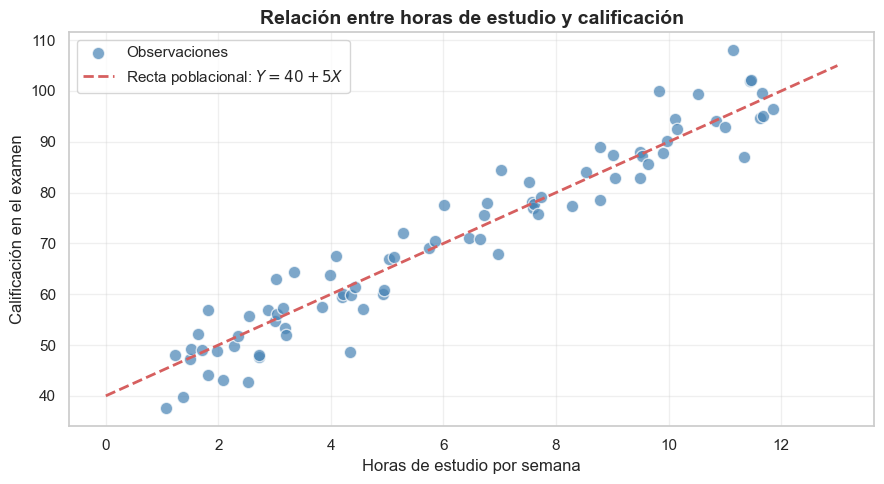

In [3]:
# Diagrama de dispersión de los datos
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(df['horas_estudio'], df['calificacion'], 
           color='steelblue', alpha=0.7, edgecolors='white', s=80, label='Observaciones')

# Recta poblacional verdadera
x_range = np.linspace(0, 13, 200)
ax.plot(x_range, beta_0_real + beta_1_real * x_range, 
        'r--', linewidth=2, label=f'Recta poblacional: $Y = {beta_0_real} + {beta_1_real}X$')

ax.set_xlabel('Horas de estudio por semana', fontsize=12)
ax.set_ylabel('Calificación en el examen', fontsize=12)
ax.set_title('Relación entre horas de estudio y calificación', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 3. Estimación por Mínimos Cuadrados Ordinarios (MCO)

### Principio
MCO busca los estimadores $\hat{\beta}_0$ y $\hat{\beta}_1$ que **minimizan la suma de cuadrados de los residuos** (SCE):

$$\text{SCE} = \sum_{i=1}^{n} e_i^2 = \sum_{i=1}^{n} (Y_i - \hat{\beta}_0 - \hat{\beta}_1 X_i)^2$$

### Fórmulas cerradas

Derivando la SCE e igualando a cero se obtienen las **ecuaciones normales**, cuya solución es:

$$\hat{\beta}_1 = \frac{\sum_{i=1}^{n}(X_i - \bar{X})(Y_i - \bar{Y})}{\sum_{i=1}^{n}(X_i - \bar{X})^2} = \frac{S_{XY}}{S_{XX}}$$

$$\hat{\beta}_0 = \bar{Y} - \hat{\beta}_1 \bar{X}$$

### Estimación de la varianza del error

La varianza del error $\sigma^2 = \text{Var}(\varepsilon_i)$ se estima con el **cuadrado medio del error** (CME):

$$\hat{\sigma}^2 = s^2 = \frac{\text{SCE}}{n - 2} = \frac{\sum_{i=1}^{n}(Y_i - \hat{Y}_i)^2}{n-2}$$

Se divide entre $n-2$ porque se estiman **2 parámetros** ($\beta_0$ y $\beta_1$), perdiendo 2 grados de libertad.


In [4]:
# ── Estimación manual de MCO ──────────────────────────────────────────────
X_arr = df['horas_estudio'].values
Y_arr = df['calificacion'].values

X_mean = np.mean(X_arr)
Y_mean = np.mean(Y_arr)

Sxx = np.sum((X_arr - X_mean) ** 2)
Sxy = np.sum((X_arr - X_mean) * (Y_arr - Y_mean))

beta1_hat = Sxy / Sxx
beta0_hat = Y_mean - beta1_hat * X_mean

Y_hat = beta0_hat + beta1_hat * X_arr
residuos = Y_arr - Y_hat

SCE = np.sum(residuos ** 2)
s2 = SCE / (n - 2)   # varianza estimada del error
s  = np.sqrt(s2)      # desviación estándar del error (error estándar de la regresión)

print("=" * 45)
print("  Estimación MCO (cálculo manual)")
print("=" * 45)
print(f"  β̂₀ (intercepto) = {beta0_hat:.4f}")
print(f"  β̂₁ (pendiente)  = {beta1_hat:.4f}")
print(f"  s² (var. error)  = {s2:.4f}")
print(f"  s  (err. estándar) = {s:.4f}")
print("=" * 45)
print(f"\n  Valores reales: β₀={beta_0_real}, β₁={beta_1_real}, σ={sigma_real}")

  Estimación MCO (cálculo manual)
  β̂₀ (intercepto) = 38.7013
  β̂₁ (pendiente)  = 5.2043
  s² (var. error)  = 23.0418
  s  (err. estándar) = 4.8002

  Valores reales: β₀=40, β₁=5, σ=5


In [5]:
# ── Estimación con statsmodels (reporte completo) ─────────────────────────
X_sm = sm.add_constant(df['horas_estudio'])   # agrega columna de unos para β₀
modelo = sm.OLS(df['calificacion'], X_sm).fit()

print(modelo.summary())

# Guardamos resultados para los diagnósticos posteriores
fitted   = modelo.fittedvalues
residuos = modelo.resid

                            OLS Regression Results                            
Dep. Variable:           calificacion   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     1050.
Date:                Thu, 28 May 2026   Prob (F-statistic):           5.26e-47
Time:                        10:27:26   Log-Likelihood:                -237.99
No. Observations:                  80   AIC:                             480.0
Df Residuals:                      78   BIC:                             484.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            38.7013      1.121     34.537

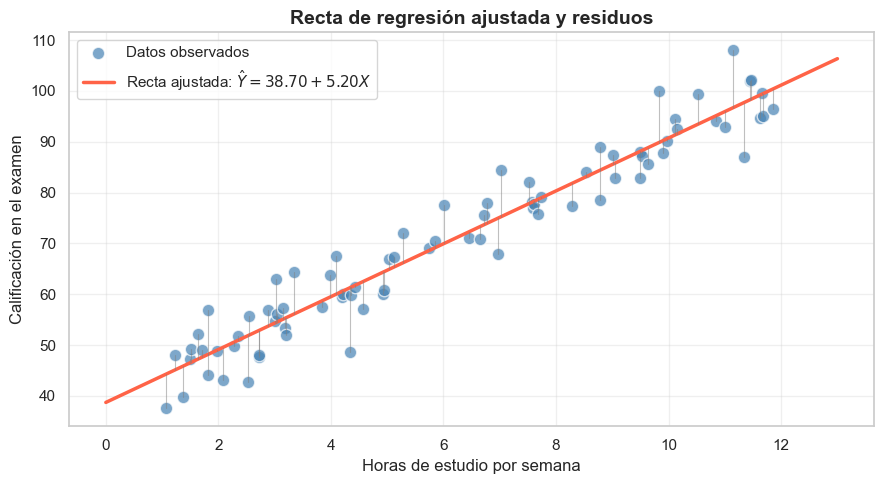

In [6]:
# ── Visualización de la recta ajustada ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(df['horas_estudio'], df['calificacion'],
           color='steelblue', alpha=0.7, edgecolors='white', s=80, label='Datos observados')

b0 = modelo.params['const']
b1 = modelo.params['horas_estudio']

x_plot = np.linspace(0, 13, 200)
ax.plot(x_plot, b0 + b1 * x_plot,
        'tomato', linewidth=2.5,
        label=f'Recta ajustada: $\\hat{{Y}} = {b0:.2f} + {b1:.2f}X$')

# Residuos (líneas verticales desde punto a recta)
for xi, yi, yhi in zip(df['horas_estudio'], df['calificacion'], fitted):
    ax.plot([xi, xi], [yi, yhi], color='gray', linewidth=0.8, alpha=0.5)

ax.set_xlabel('Horas de estudio por semana', fontsize=12)
ax.set_ylabel('Calificación en el examen', fontsize=12)
ax.set_title('Recta de regresión ajustada y residuos', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 4. Los Supuestos del Modelo de Regresión Lineal Simple

Para que los estimadores MCO sean válidos —tanto en términos de eficiencia como de inferencia— deben cumplirse los siguientes supuestos sobre el término de error $\varepsilon_i$:

| # | Supuesto | Notación |
|---|----------|----------|
| **S1** | **Linealidad** del modelo en los parámetros | $E[\varepsilon_i] = 0$ |
| **S2** | **Independencia** de los errores | $\text{Cov}(\varepsilon_i, \varepsilon_j) = 0, \; i \neq j$ |
| **S3** | **Homocedasticidad** (varianza constante) | $\text{Var}(\varepsilon_i) = \sigma^2$ (constante) |
| **S4** | **Normalidad** de los errores | $\varepsilon_i \sim N(0, \sigma^2)$ |
| **S5** | **Ausencia de observaciones influyentes** | No hay outliers que distorsionen la estimación |

> Los supuestos S1–S3 son necesarios para el **Teorema de Gauss-Markov** (MCO = MELI: Mejor Estimador Lineal Insesgado).  
> El supuesto S4 (normalidad) es adicional y necesario para realizar **inferencia estadística** (pruebas $t$ e $F$, intervalos de confianza).

---

A continuación verificaremos cada supuesto con **gráficos diagnósticos** y **pruebas estadísticas** formales.


### Supuesto 1 — Linealidad

**Enunciado**: La relación entre $X$ e $Y$ es **lineal en los parámetros**, es decir, $E[Y|X] = \beta_0 + \beta_1 X$.

**¿Qué implica?** Los residuos deben distribuirse aleatoriamente alrededor de cero, sin ningún patrón sistemático en función de los valores ajustados.

**Cómo verificarlo:**
- **Gráfico de residuos vs. valores ajustados** ($e_i$ vs. $\hat{Y}_i$): si hay linealidad, los residuos deben estar dispersos aleatoriamente alrededor de la línea $e=0$, sin formas curvilíneas.
- **Gráfico de dispersión** ($Y$ vs. $X$): inspección visual directa.

**Señales de no linealidad:**
- Forma de "U" o arco en el gráfico de residuos
- Tendencias sistemáticas crecientes o decrecientes en los residuos

**Solución si se viola:** Transformaciones de las variables (ej. $\ln(X)$, $X^2$), o modelos no lineales.

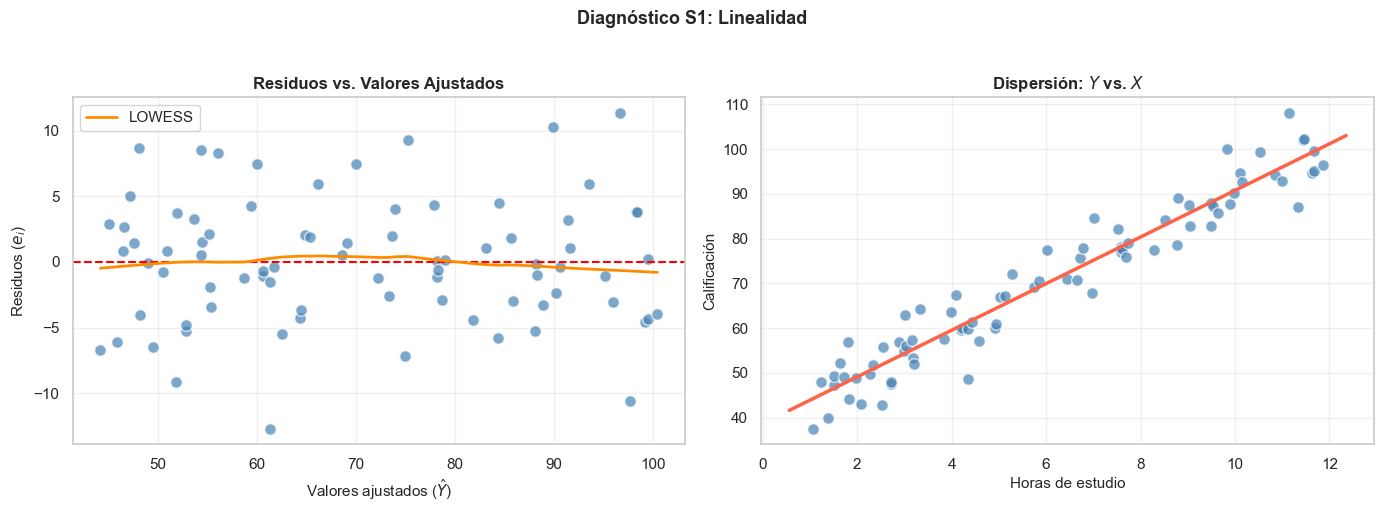

✓ Interpretación: La curva LOWESS debe seguir aproximadamente la línea y=0.
  Si la curva es aproximadamente horizontal, el supuesto de linealidad se cumple.


In [7]:
# ── S1: Verificación de Linealidad ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

b0 = modelo.params['const']
b1 = modelo.params['horas_estudio']

# Gráfico 1: residuos vs. valores ajustados
axes[0].scatter(fitted, residuos, color='steelblue', alpha=0.7, edgecolors='white', s=70)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
# Línea suavizada (LOWESS)
lowess_fit = sm.nonparametric.lowess(residuos, fitted, frac=0.5)
axes[0].plot(lowess_fit[:, 0], lowess_fit[:, 1], color='darkorange', linewidth=2, label='LOWESS')
axes[0].set_xlabel('Valores ajustados ($\\hat{Y}$)', fontsize=11)
axes[0].set_ylabel('Residuos ($e_i$)', fontsize=11)
axes[0].set_title('Residuos vs. Valores Ajustados', fontsize=12, fontweight='bold')
axes[0].legend()

# Gráfico 2: Y vs. X con recta ajustada
axes[1].scatter(df['horas_estudio'], df['calificacion'],
                color='steelblue', alpha=0.7, edgecolors='white', s=70)
x_plot = np.linspace(df['horas_estudio'].min() - 0.5, df['horas_estudio'].max() + 0.5, 200)
axes[1].plot(x_plot, b0 + b1 * x_plot,
             color='tomato', linewidth=2.5)
axes[1].set_xlabel('Horas de estudio', fontsize=11)
axes[1].set_ylabel('Calificación', fontsize=11)
axes[1].set_title('Dispersión: $Y$ vs. $X$', fontsize=12, fontweight='bold')

plt.suptitle('Diagnóstico S1: Linealidad', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("✓ Interpretación: La curva LOWESS debe seguir aproximadamente la línea y=0.")
print("  Si la curva es aproximadamente horizontal, el supuesto de linealidad se cumple.")

### Supuesto 2 — Independencia de los errores

**Enunciado**: Los errores son **no correlacionados** entre sí:

$$\text{Cov}(\varepsilon_i, \varepsilon_j) = 0, \quad \forall \; i \neq j$$

**¿Qué implica?** El error de una observación no debe depender del error de otra. Esto es crucial especialmente cuando los datos tienen una estructura **temporal o espacial** (series de tiempo, datos georreferenciados).

**Cómo verificarlo:**
- **Gráfico de residuos vs. orden de observación**: si los residuos forman patrones ondulantes, hay autocorrelación.
- **Prueba de Durbin-Watson**: contrasta $H_0$: no hay autocorrelación de primer orden.

$$DW = \frac{\sum_{i=2}^{n}(e_i - e_{i-1})^2}{\sum_{i=1}^{n} e_i^2}$$

**Valores de referencia del estadístico DW:**

| Rango | Interpretación |
|-------|---------------|
| $DW \approx 2$ | No hay autocorrelación → supuesto OK ✓ |
| $DW < 1.5$ | Autocorrelación positiva → problema ✗ |
| $DW > 2.5$ | Autocorrelación negativa → problema ✗ |

**Solución si se viola:** Modelos con errores correlacionados (ARIMA, GLS), o incluir variables rezagadas.

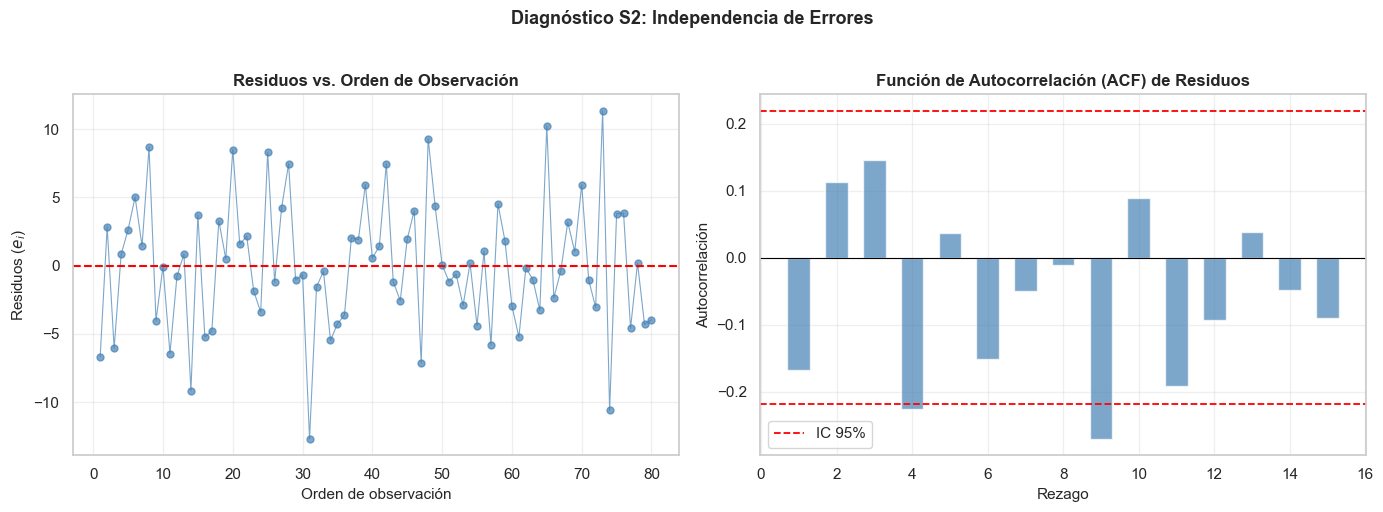

Estadístico Durbin-Watson: DW = 2.2948
✓ Resultado: DW ≈ 2 → No se detecta autocorrelación. Supuesto CUMPLIDO.


In [8]:
# ── S2: Verificación de Independencia (Durbin-Watson) ─────────────────────
dw_stat = durbin_watson(residuos)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: residuos vs. orden de observación
axes[0].plot(range(1, n + 1), residuos, 'o-', color='steelblue', 
             markersize=5, alpha=0.7, linewidth=0.8)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Orden de observación', fontsize=11)
axes[0].set_ylabel('Residuos ($e_i$)', fontsize=11)
axes[0].set_title('Residuos vs. Orden de Observación', fontsize=12, fontweight='bold')

# Gráfico 2: autocorrelación de residuos (ACF manual)
lags = range(1, 16)
acf_vals = [np.corrcoef(residuos[:-k], residuos[k:])[0, 1] for k in lags]
IC = 1.96 / np.sqrt(n)   # intervalo de confianza aproximado al 95%

axes[1].bar(lags, acf_vals, color='steelblue', alpha=0.7, width=0.6)
axes[1].axhline(IC,  color='red', linestyle='--', linewidth=1.3, label='IC 95%')
axes[1].axhline(-IC, color='red', linestyle='--', linewidth=1.3)
axes[1].axhline(0,   color='black', linewidth=0.8)
axes[1].set_xlabel('Rezago', fontsize=11)
axes[1].set_ylabel('Autocorrelación', fontsize=11)
axes[1].set_title('Función de Autocorrelación (ACF) de Residuos', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('Diagnóstico S2: Independencia de Errores', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Estadístico Durbin-Watson: DW = {dw_stat:.4f}")
if 1.5 <= dw_stat <= 2.5:
    print("✓ Resultado: DW ≈ 2 → No se detecta autocorrelación. Supuesto CUMPLIDO.")
else:
    print("✗ Resultado: DW fuera del rango [1.5, 2.5] → Posible autocorrelación.")

### Supuesto 3 — Homocedasticidad (varianza constante)

**Enunciado**: La varianza del error es **constante** para todas las observaciones:

$$\text{Var}(\varepsilon_i) = \sigma^2 \quad \forall \; i$$

Si la varianza cambia con $X$ o con $\hat{Y}$, se dice que hay **heterocedasticidad**.

**¿Qué implica?** La heterocedasticidad no sesga los estimadores, pero los hace **ineficientes** y los errores estándar quedan mal calculados, invalidando las pruebas de hipótesis.

**Cómo verificarlo:**

| Método | Descripción |
|--------|-------------|
| **Gráfico Scale-Location** | Raíz de \|residuos estandarizados\| vs. $\hat{Y}$. Debe ser una banda horizontal |
| **Gráfico residuos vs. $\hat{Y}$** | La dispersión debe ser uniforme en todo el rango |
| **Prueba de Breusch-Pagan** | $H_0$: homocedasticidad. $p > 0.05$ → no se rechaza → OK |
| **Prueba de White** | Similar a BP, más general. No requiere especificar la forma de la heterocedasticidad |

**Estadístico de Breusch-Pagan:**
Regresión auxiliar de $e_i^2$ sobre $X_i$. El estadístico $BP = nR^2_{aux} \sim \chi^2_{(k)}$ donde $k$ es el número de regresores.

**Solución si se viola:** Errores estándar robustos (HC), transformación de $Y$ (ej. $\ln Y$), o Mínimos Cuadrados Ponderados (MCP).

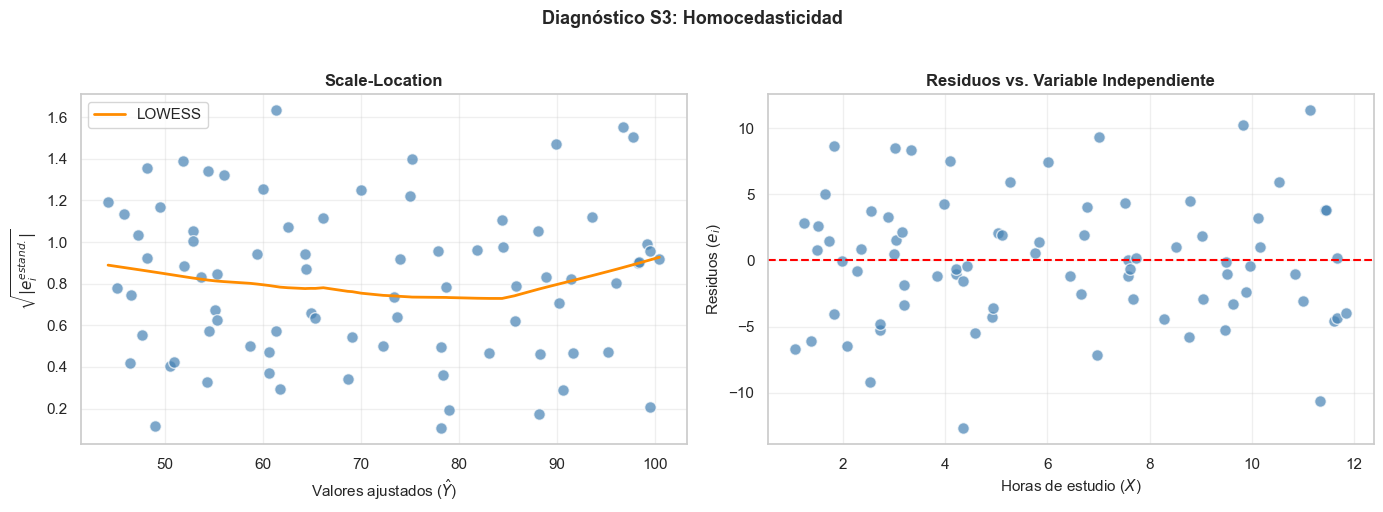

  Prueba de Breusch-Pagan
  Estadístico LM : 0.0126
  p-valor        : 0.9105
  Conclusión     : ✓ No se rechaza H₀ → Homocedasticidad

  Prueba de White
  Estadístico LM : 0.7348
  p-valor        : 0.6925
  Conclusión     : ✓ No se rechaza H₀ → Homocedasticidad


In [9]:
# ── S3: Verificación de Homocedasticidad ─────────────────────────────────
# Residuos estandarizados
influence = modelo.get_influence()
resid_std = influence.resid_studentized_internal

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Scale-Location (√|residuos estandarizados| vs. ajustados)
sqrt_abs_resid = np.sqrt(np.abs(resid_std))
axes[0].scatter(fitted, sqrt_abs_resid, color='steelblue', alpha=0.7, 
                edgecolors='white', s=70)
lowess_sl = sm.nonparametric.lowess(sqrt_abs_resid, fitted, frac=0.5)
axes[0].plot(lowess_sl[:, 0], lowess_sl[:, 1], color='darkorange', linewidth=2, label='LOWESS')
axes[0].set_xlabel('Valores ajustados ($\\hat{Y}$)', fontsize=11)
axes[0].set_ylabel('$\\sqrt{|e_i^{estand.}|}$', fontsize=11)
axes[0].set_title('Scale-Location', fontsize=12, fontweight='bold')
axes[0].legend()

# Gráfico 2: residuos vs. X (para ver si la varianza cambia con X)
axes[1].scatter(df['horas_estudio'], residuos, color='steelblue', alpha=0.7,
                edgecolors='white', s=70)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Horas de estudio ($X$)', fontsize=11)
axes[1].set_ylabel('Residuos ($e_i$)', fontsize=11)
axes[1].set_title('Residuos vs. Variable Independiente', fontsize=12, fontweight='bold')

plt.suptitle('Diagnóstico S3: Homocedasticidad', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Prueba de Breusch-Pagan
bp_stat, bp_pvalue, bp_f, bp_f_pvalue = het_breuschpagan(residuos, X_sm)

# Prueba de White
white_stat, white_pvalue, white_f, white_f_pvalue = het_white(residuos, X_sm)

print("=" * 52)
print("  Prueba de Breusch-Pagan")
print("=" * 52)
print(f"  Estadístico LM : {bp_stat:.4f}")
print(f"  p-valor        : {bp_pvalue:.4f}")
resultado_bp = "✓ No se rechaza H₀ → Homocedasticidad" if bp_pvalue > 0.05 else "✗ Se rechaza H₀ → Heterocedasticidad"
print(f"  Conclusión     : {resultado_bp}")

print("\n" + "=" * 52)
print("  Prueba de White")
print("=" * 52)
print(f"  Estadístico LM : {white_stat:.4f}")
print(f"  p-valor        : {white_pvalue:.4f}")
resultado_w = "✓ No se rechaza H₀ → Homocedasticidad" if white_pvalue > 0.05 else "✗ Se rechaza H₀ → Heterocedasticidad"
print(f"  Conclusión     : {resultado_w}")

### Supuesto 4 — Normalidad de los errores

**Enunciado**: Los errores siguen una distribución normal con media cero y varianza constante:

$$\varepsilon_i \sim N(0, \sigma^2)$$

**¿Qué implica?** Este supuesto es necesario para que las estadísticas $t$ y $F$ usadas en las pruebas de hipótesis tengan sus distribuciones exactas. Para muestras grandes ($n > 30$), el Teorema Central del Límite atenúa su importancia.

**Cómo verificarlo:**

| Método | Qué busca |
|--------|-----------|
| **Histograma de residuos** | Forma aproximadamente de campana |
| **Gráfico Q-Q Normal** | Los puntos deben alinearse sobre la diagonal $y = x$ |
| **Prueba de Shapiro-Wilk** | $H_0$: los residuos son normales. $p > 0.05$ → no se rechaza → OK (recomendada para $n < 50$) |
| **Prueba de Kolmogorov-Smirnov** | Similar a Shapiro-Wilk, más apropiada para muestras grandes |

**Señales de no normalidad:**
- Colas pesadas o ligeras en el Q-Q plot (puntos se alejan de la diagonal en los extremos)
- Asimetría marcada en el histograma

**Solución si se viola:** Transformación Box-Cox de $Y$, o métodos no paramétricos.

/Users/nataliaacevedo/MisCursos/venv/lib/python3.11/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.2823529411764706, 0.47058823529411764, 0.8156862745098039, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


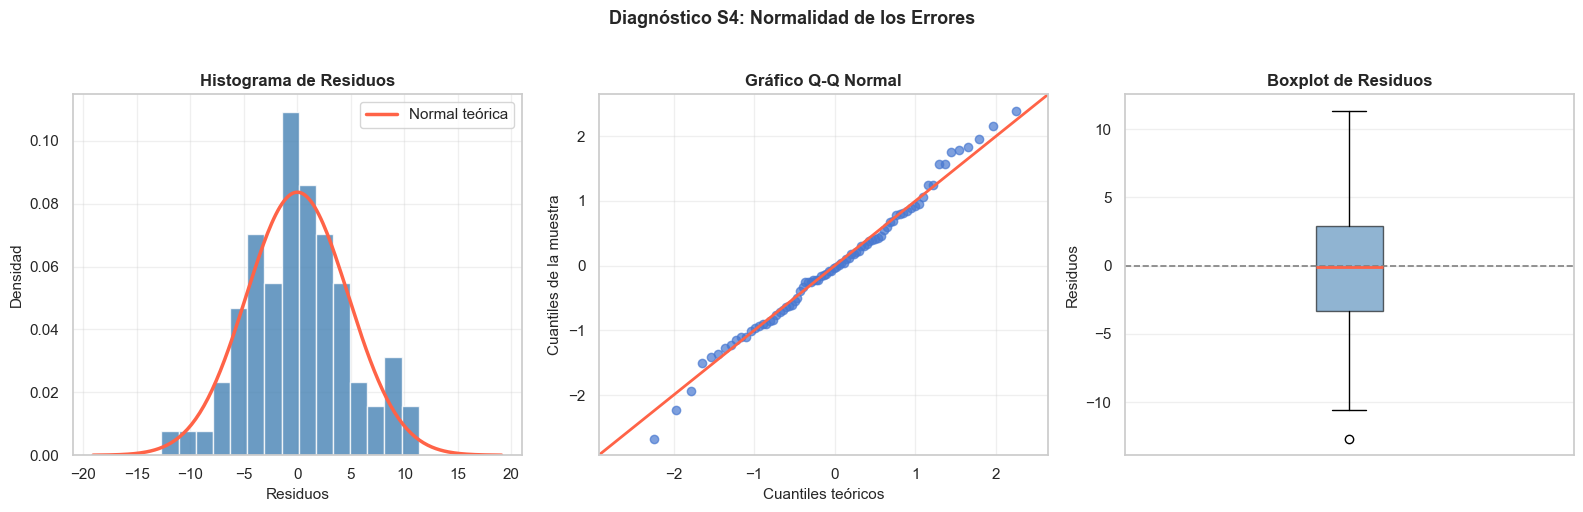

  Prueba de Shapiro-Wilk
  Estadístico W  : 0.9918
  p-valor        : 0.8939
  Conclusión     : ✓ No se rechaza H₀ → Normalidad

  Prueba de Kolmogorov-Smirnov
  Estadístico D  : 0.0506
  p-valor        : 0.9801
  Conclusión     : ✓ No se rechaza H₀ → Normalidad


In [10]:
# ── S4: Verificación de Normalidad de los Residuos ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfico 1: Histograma de residuos
axes[0].hist(residuos, bins=15, color='steelblue', edgecolor='white', alpha=0.8, density=True)
# Curva normal superpuesta
mu_res, std_res = residuos.mean(), residuos.std()
x_norm = np.linspace(mu_res - 4 * std_res, mu_res + 4 * std_res, 200)
axes[0].plot(x_norm, stats.norm.pdf(x_norm, mu_res, std_res), 
             color='tomato', linewidth=2.5, label='Normal teórica')
axes[0].set_xlabel('Residuos', fontsize=11)
axes[0].set_ylabel('Densidad', fontsize=11)
axes[0].set_title('Histograma de Residuos', fontsize=12, fontweight='bold')
axes[0].legend()

# Gráfico 2: Q-Q Plot
pp = ProbPlot(residuos, fit=True)
qq = pp.qqplot(ax=axes[1], line='45', alpha=0.7, color='steelblue')
axes[1].get_lines()[1].set(color='tomato', linewidth=2)  # línea de referencia
axes[1].set_title('Gráfico Q-Q Normal', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cuantiles teóricos', fontsize=11)
axes[1].set_ylabel('Cuantiles de la muestra', fontsize=11)

# Gráfico 3: Boxplot de residuos
axes[2].boxplot(residuos, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='tomato', linewidth=2))
axes[2].axhline(0, color='gray', linestyle='--', linewidth=1.2)
axes[2].set_ylabel('Residuos', fontsize=11)
axes[2].set_title('Boxplot de Residuos', fontsize=12, fontweight='bold')
axes[2].set_xticks([])

plt.suptitle('Diagnóstico S4: Normalidad de los Errores', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Pruebas formales
sw_stat, sw_pvalue = shapiro(residuos)
ks_stat, ks_pvalue = kstest(residuos, 'norm', args=(residuos.mean(), residuos.std()))

print("=" * 52)
print("  Prueba de Shapiro-Wilk")
print("=" * 52)
print(f"  Estadístico W  : {sw_stat:.4f}")
print(f"  p-valor        : {sw_pvalue:.4f}")
res_sw = "✓ No se rechaza H₀ → Normalidad" if sw_pvalue > 0.05 else "✗ Se rechaza H₀ → No normalidad"
print(f"  Conclusión     : {res_sw}")

print("\n" + "=" * 52)
print("  Prueba de Kolmogorov-Smirnov")
print("=" * 52)
print(f"  Estadístico D  : {ks_stat:.4f}")
print(f"  p-valor        : {ks_pvalue:.4f}")
res_ks = "✓ No se rechaza H₀ → Normalidad" if ks_pvalue > 0.05 else "✗ Se rechaza H₀ → No normalidad"
print(f"  Conclusión     : {res_ks}")

### Supuesto 5 — Ausencia de observaciones influyentes

**Enunciado**: No existen observaciones que, por su posición extrema, distorsionen significativamente los estimadores MCO.

**Tipos de observaciones problemáticas:**

| Tipo | Definición | Medida |
|------|-----------|--------|
| **Outlier** | Valor atípico en $Y$ (residuo grande) | Residuo estandarizado $\|e_i^*\| > 2$ |
| **Punto de influencia** (leverage) | Valor atípico en $X$ (posición extrema) | $h_{ii} > 2(k+1)/n$ |
| **Observación influyente** | Distorsiona los estimadores al eliminarse | Distancia de Cook $D_i > 4/n$ |

#### Distancia de Cook

Mide cuánto cambiarían los estimadores si se elimina la observación $i$:

$$D_i = \frac{(\hat{\boldsymbol{\beta}} - \hat{\boldsymbol{\beta}}_{(-i)})^T (X^TX)(\hat{\boldsymbol{\beta}} - \hat{\boldsymbol{\beta}}_{(-i)})}{(k+1)s^2}$$

Una aproximación práctica es:
$$D_i \approx \frac{e_i^{*2}}{k+1} \cdot \frac{h_{ii}}{1 - h_{ii}}$$

**Regla de decisión:** $D_i > 4/n$ o $D_i > 1$ → observación potencialmente influyente.

**Leverage (apalancamiento)**:

$$h_{ii} = \frac{1}{n} + \frac{(X_i - \bar{X})^2}{\sum_{j=1}^{n}(X_j - \bar{X})^2}$$

Valores altos de $h_{ii}$ indican que la observación $i$ tiene un valor de $X$ muy alejado de la media.

**Solución si hay influyentes:** Investigar si son errores de captura, o ejecutar la regresión con y sin ellos para comparar resultados.

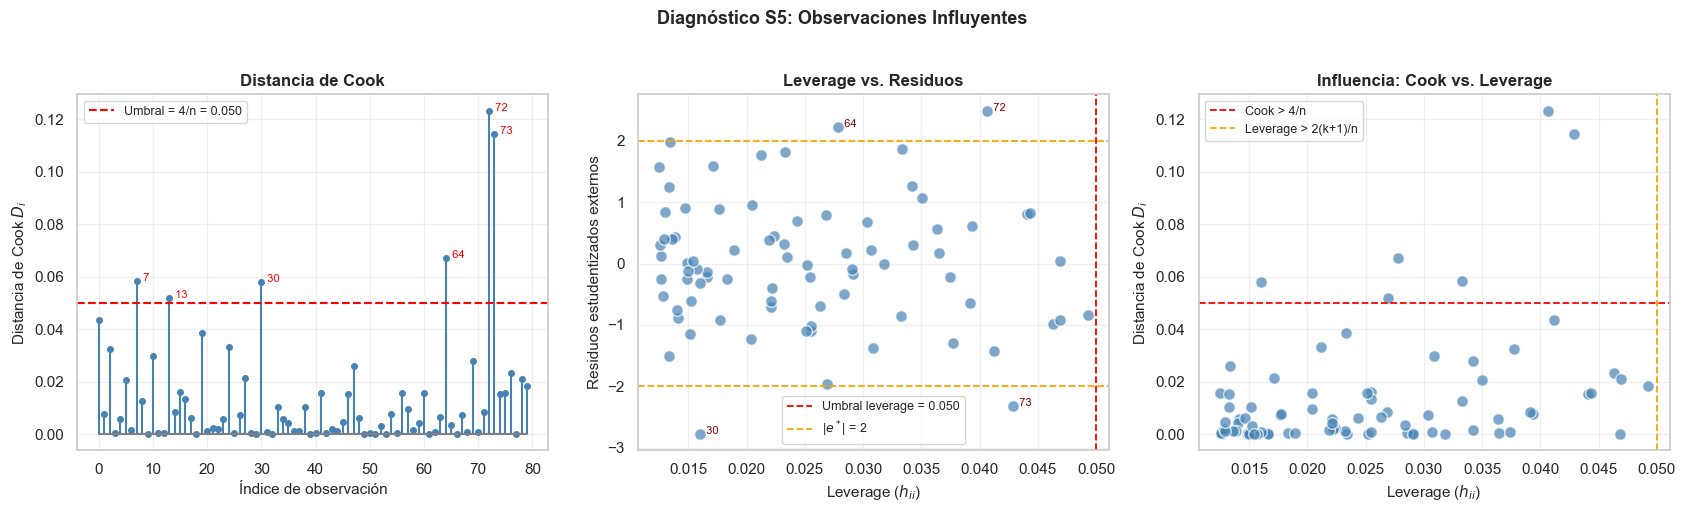

Umbral Distancia de Cook (4/n = 0.0500): 6 observaciones superan el umbral
Umbral de Leverage   (2(k+1)/n = 0.0500): 0 observaciones superan el umbral
Outliers (|residuo estudentizado| > 2)           : 4 observaciones

⚠ Revisar las observaciones señaladas. Investigar si son errores de captura.


In [11]:
# ── S5: Verificación de Observaciones Influyentes ─────────────────────────
influence = modelo.get_influence()
cooks_d, _ = influence.cooks_distance
leverage   = influence.hat_matrix_diag
resid_ext  = influence.resid_studentized_external   # residuos estudentizados externos

umbral_cook = 4 / n
umbral_lev  = 2 * 2 / n   # 2*(k+1)/n con k=1

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Gráfico 1: Distancia de Cook
markerline, stemlines, baseline = axes[0].stem(
    range(n), cooks_d, linefmt='steelblue', markerfmt='o', basefmt='gray')
markerline.set_markersize(4)
axes[0].axhline(umbral_cook, color='red', linestyle='--', linewidth=1.5,
                label=f'Umbral = 4/n = {umbral_cook:.3f}')
# Etiquetar influyentes
for i in np.where(cooks_d > umbral_cook)[0]:
    axes[0].annotate(f'  {i}', (i, cooks_d[i]), fontsize=8, color='red')
axes[0].set_xlabel('Índice de observación', fontsize=11)
axes[0].set_ylabel("Distancia de Cook $D_i$", fontsize=11)
axes[0].set_title('Distancia de Cook', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Gráfico 2: Leverage vs. residuos estandarizados
axes[1].scatter(leverage, resid_ext, color='steelblue', alpha=0.7, 
                edgecolors='white', s=70)
axes[1].axvline(umbral_lev, color='red', linestyle='--', linewidth=1.3,
                label=f'Umbral leverage = {umbral_lev:.3f}')
axes[1].axhline(2,  color='orange', linestyle='--', linewidth=1.3)
axes[1].axhline(-2, color='orange', linestyle='--', linewidth=1.3, label='|$e^*$| = 2')
# Etiquetar puntos en esquinas problemáticas
for i in range(n):
    if leverage[i] > umbral_lev or abs(resid_ext[i]) > 2:
        axes[1].annotate(f'  {i}', (leverage[i], resid_ext[i]), fontsize=8, color='darkred')
axes[1].set_xlabel('Leverage ($h_{ii}$)', fontsize=11)
axes[1].set_ylabel('Residuos estudentizados externos', fontsize=11)
axes[1].set_title('Leverage vs. Residuos', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

# Gráfico 3: Gráfico de influencia (Cook vs. leverage)
axes[2].scatter(leverage, cooks_d, color='steelblue', alpha=0.7,
                edgecolors='white', s=70)
axes[2].axhline(umbral_cook, color='red', linestyle='--', linewidth=1.3,
                label=f'Cook > 4/n')
axes[2].axvline(umbral_lev, color='orange', linestyle='--', linewidth=1.3,
                label=f'Leverage > 2(k+1)/n')
axes[2].set_xlabel('Leverage ($h_{ii}$)', fontsize=11)
axes[2].set_ylabel('Distancia de Cook $D_i$', fontsize=11)
axes[2].set_title('Influencia: Cook vs. Leverage', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Diagnóstico S5: Observaciones Influyentes', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Resumen numérico
n_cooks = np.sum(cooks_d > umbral_cook)
n_lev   = np.sum(leverage > umbral_lev)
n_outl  = np.sum(np.abs(resid_ext) > 2)

print(f"Umbral Distancia de Cook (4/n = {umbral_cook:.4f}): {n_cooks} observaciones superan el umbral")
print(f"Umbral de Leverage   (2(k+1)/n = {umbral_lev:.4f}): {n_lev} observaciones superan el umbral")
print(f"Outliers (|residuo estudentizado| > 2)           : {n_outl} observaciones")

if n_cooks == 0 and n_outl == 0:
    print("\n✓ No se detectan observaciones influyentes problemáticas. Supuesto CUMPLIDO.")
else:
    print("\n⚠ Revisar las observaciones señaladas. Investigar si son errores de captura.")

## 5. Panel de Diagnóstico Completo

Una práctica recomendada es visualizar los cuatro gráficos diagnósticos clásicos en un solo panel, de forma análoga a `plot(lm_model)` en R.


/Users/nataliaacevedo/MisCursos/venv/lib/python3.11/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.2823529411764706, 0.47058823529411764, 0.8156862745098039, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


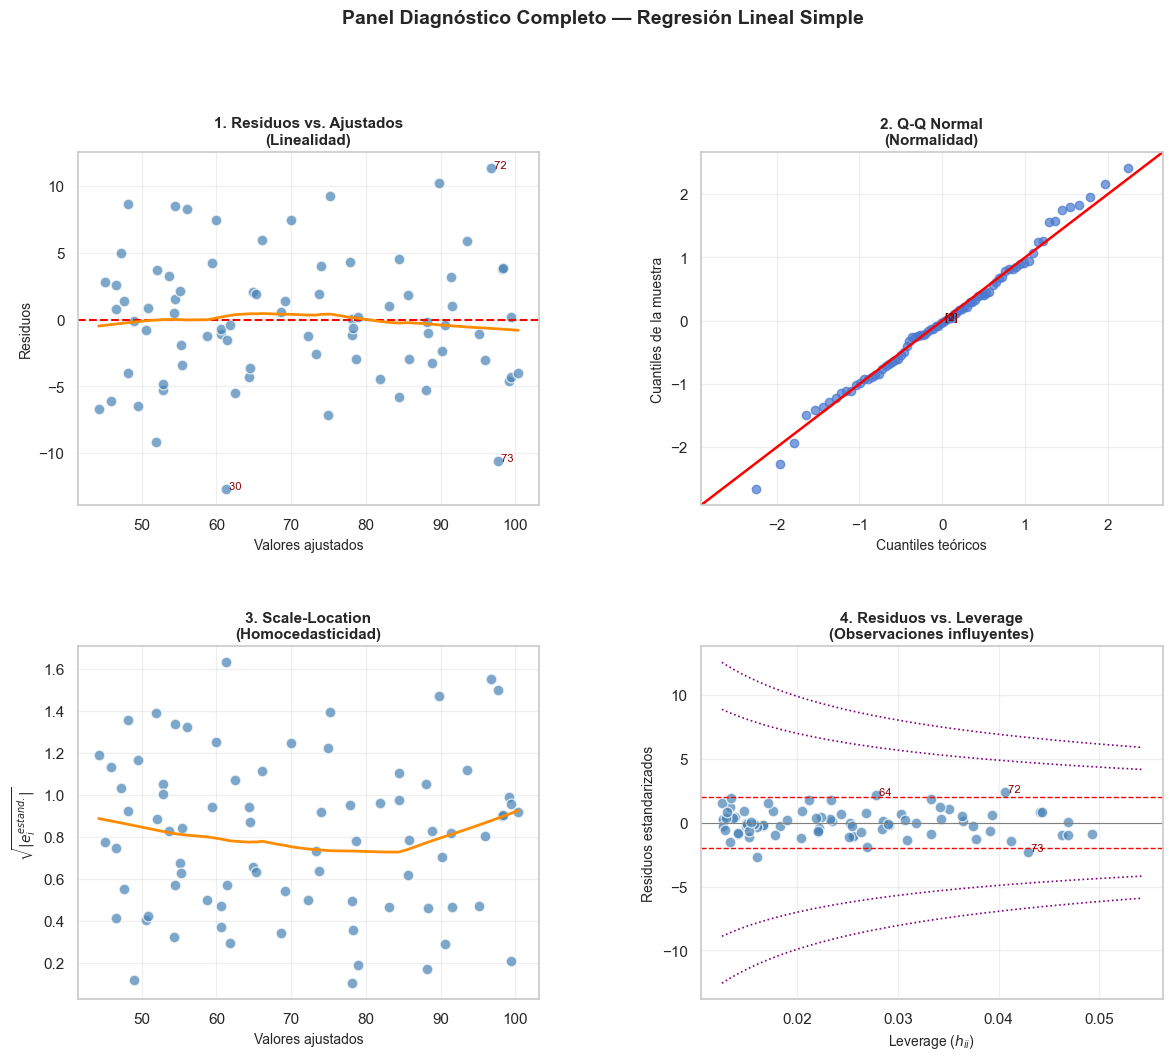

In [12]:
# ── Panel diagnóstico completo (4 gráficos clásicos) ─────────────────────
fig = plt.figure(figsize=(14, 11))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

influence    = modelo.get_influence()
resid_std    = influence.resid_studentized_internal
resid_ext    = influence.resid_studentized_external
cooks_d, _   = influence.cooks_distance
leverage     = influence.hat_matrix_diag
sqrt_abs_std = np.sqrt(np.abs(resid_std))

# ─── 1. Residuos vs. Ajustados (Linealidad) ───────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(fitted, residuos, color='steelblue', alpha=0.7, edgecolors='white', s=60)
ax1.axhline(0, color='red', linestyle='--', linewidth=1.5)
lw = sm.nonparametric.lowess(residuos, fitted, frac=0.5)
ax1.plot(lw[:, 0], lw[:, 1], color='darkorange', linewidth=2)
# Etiquetar los 3 residuos más extremos
top3 = np.argsort(np.abs(residuos))[-3:]
for i in top3:
    ax1.annotate(f' {i}', (fitted.iloc[i], residuos.iloc[i]), fontsize=8, color='darkred')
ax1.set_xlabel('Valores ajustados', fontsize=10); ax1.set_ylabel('Residuos', fontsize=10)
ax1.set_title('1. Residuos vs. Ajustados\n(Linealidad)', fontsize=11, fontweight='bold')

# ─── 2. Q-Q Normal (Normalidad) ───────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
pp = ProbPlot(resid_std, fit=True)
pp.qqplot(ax=ax2, line='45', alpha=0.7, color='steelblue')
ax2.get_lines()[1].set(color='red', linewidth=1.8)
top3_qq = np.argsort(np.abs(resid_std))[-3:]
q_theor = stats.norm.ppf(np.linspace(0.01, 0.99, n))
q_samp  = np.sort(resid_std)
for i in top3_qq:
    ax2.annotate(f' {np.where(np.sort(np.abs(resid_std))[::-1][:3] == np.abs(resid_std[i]))[0]}',
                 (0, 0), fontsize=8, color='darkred')
ax2.set_xlabel('Cuantiles teóricos', fontsize=10); ax2.set_ylabel('Cuantiles de la muestra', fontsize=10)
ax2.set_title('2. Q-Q Normal\n(Normalidad)', fontsize=11, fontweight='bold')

# ─── 3. Scale-Location (Homocedasticidad) ─────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(fitted, sqrt_abs_std, color='steelblue', alpha=0.7, edgecolors='white', s=60)
lw3 = sm.nonparametric.lowess(sqrt_abs_std, fitted, frac=0.5)
ax3.plot(lw3[:, 0], lw3[:, 1], color='darkorange', linewidth=2)
ax3.set_xlabel('Valores ajustados', fontsize=10)
ax3.set_ylabel('$\\sqrt{|e_i^{estand.}|}$', fontsize=10)
ax3.set_title('3. Scale-Location\n(Homocedasticidad)', fontsize=11, fontweight='bold')

# ─── 4. Residuos vs. Leverage (Influencia) ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(leverage, resid_std, color='steelblue', alpha=0.7, edgecolors='white', s=60)
ax4.axhline(0, color='gray', linewidth=0.8)
ax4.axhline(2,  color='red', linestyle='--', linewidth=1)
ax4.axhline(-2, color='red', linestyle='--', linewidth=1)
# Curvas de Cook
x_lev = np.linspace(leverage.min(), leverage.max() * 1.1, 200)
for d in [0.5, 1.0]:
    cook_line = np.sqrt(d * 2 * (1 - x_lev) / x_lev)
    ax4.plot(x_lev, cook_line, ':', color='purple', linewidth=1.2)
    ax4.plot(x_lev, -cook_line, ':', color='purple', linewidth=1.2)
top_inf = np.argsort(cooks_d)[-3:]
for i in top_inf:
    ax4.annotate(f' {i}', (leverage[i], resid_std[i]), fontsize=8, color='darkred')
ax4.set_xlabel('Leverage ($h_{ii}$)', fontsize=10)
ax4.set_ylabel('Residuos estandarizados', fontsize=10)
ax4.set_title('4. Residuos vs. Leverage\n(Observaciones influyentes)', fontsize=11, fontweight='bold')

fig.suptitle('Panel Diagnóstico Completo — Regresión Lineal Simple', 
             fontsize=14, fontweight='bold', y=1.01)
plt.show()

## 6. Resumen de los Resultados del Diagnóstico

La siguiente tabla consolida todos los resultados de las verificaciones realizadas:


In [13]:
# ── Tabla resumen del diagnóstico de supuestos ────────────────────────────
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residuos)
bp_s, bp_p, _, _ = het_breuschpagan(residuos, X_sm)
wh_s, wh_p, _, _ = het_white(residuos, X_sm)
sw_s, sw_p       = shapiro(residuos)

def estado(p, umbral=0.05, invertir=False):
    """Retorna '✓ OK' si p > umbral (no se rechaza H0)."""
    cumple = p > umbral
    if invertir:
        cumple = not cumple
    return "✓ CUMPLIDO" if cumple else "✗ VIOLADO"

def dw_estado(dw_val):
    return "✓ CUMPLIDO" if 1.5 <= dw_val <= 2.5 else "✗ VIOLADO"

resumen = pd.DataFrame({
    'Supuesto': [
        'S1 — Linealidad',
        'S2 — Independencia',
        'S3 — Homocedasticidad (Breusch-Pagan)',
        'S3 — Homocedasticidad (White)',
        'S4 — Normalidad (Shapiro-Wilk)',
        'S5 — No influyentes (Cook > 4/n)',
    ],
    'Prueba / Criterio': [
        'Gráfico residuos vs. ajustados (LOWESS)',
        f'Durbin-Watson = {dw:.4f}',
        f'Estadístico LM = {bp_s:.4f}',
        f'Estadístico LM = {wh_s:.4f}',
        f'Estadístico W  = {sw_s:.4f}',
        f'Observaciones con D_i > {umbral_cook:.3f}: {n_cooks}',
    ],
    'p-valor': [
        '—',
        '—',
        f'{bp_p:.4f}',
        f'{wh_p:.4f}',
        f'{sw_p:.4f}',
        '—',
    ],
    'Resultado': [
        '✓ CUMPLIDO (visual)',
        dw_estado(dw),
        estado(bp_p),
        estado(wh_p),
        estado(sw_p),
        "✓ CUMPLIDO" if n_cooks == 0 else f"⚠ {n_cooks} obs. influyentes",
    ]
})

print(resumen.to_string(index=False))

                             Supuesto                       Prueba / Criterio p-valor            Resultado
                      S1 — Linealidad Gráfico residuos vs. ajustados (LOWESS)       —  ✓ CUMPLIDO (visual)
                   S2 — Independencia                  Durbin-Watson = 2.2948       —           ✓ CUMPLIDO
S3 — Homocedasticidad (Breusch-Pagan)                 Estadístico LM = 0.0126  0.9105           ✓ CUMPLIDO
        S3 — Homocedasticidad (White)                 Estadístico LM = 0.7348  0.6925           ✓ CUMPLIDO
       S4 — Normalidad (Shapiro-Wilk)                 Estadístico W  = 0.9918  0.8939           ✓ CUMPLIDO
     S5 — No influyentes (Cook > 4/n)        Observaciones con D_i > 0.050: 6       — ⚠ 6 obs. influyentes


## 7. Conclusiones

### Interpretación del modelo ajustado

Con los datos del ejemplo:

$$\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1 X = \hat{\beta}_0 + \hat{\beta}_1 \cdot \text{horas\_estudio}$$

- **$\hat{\beta}_0$**: Calificación esperada cuando un estudiante estudia 0 horas (valor teórico del intercepto).
- **$\hat{\beta}_1$**: Por cada hora adicional de estudio por semana, la calificación esperada **aumenta en $\hat{\beta}_1$ puntos**.

### Checklist final antes de interpretar un modelo de regresión

Antes de reportar resultados, verifica sistemáticamente:

- [ ] **S1 - Linealidad**: Gráfico de residuos vs. ajustados sin patron sistemático
- [ ] **S2 - Independencia**: Durbin-Watson entre 1.5 y 2.5
- [ ] **S3 - Homocedasticidad**: Breusch-Pagan y/o White con $p > 0.05$
- [ ] **S4 - Normalidad**: Shapiro-Wilk con $p > 0.05$; Q-Q plot sin desviaciones graves
- [ ] **S5 - Sin influyentes**: Distancia de Cook $< 4/n$ para todas las observaciones

### Guía de acciones correctivas

| Supuesto violado | Acción recomendada |
|-----------------|-------------------|
| **No linealidad** | Transformar $X$ (ln, cuadrada), agregar términos polinómicos |
| **Autocorrelación** | GLS, ARIMA, variables rezagadas |
| **Heterocedasticidad** | Errores robustos HC, MCP, transformar $Y$ |
| **No normalidad** | Transformación Box-Cox de $Y$, métodos no paramétricos |
| **Observaciones influyentes** | Investigar causa, ejecutar con/sin la obs., regresión robusta |

---

> **Nota importante**: En la práctica, los supuestos raramente se cumplen perfectamente. El objetivo es verificar que no existen **violaciones graves** que invaliden las inferencias. Para muestras grandes ($n > 50$), la normalidad tiene menor importancia gracias al TCL.
